# EDA Question 10: Price vs Demand Analysis
## Amazon India Sales Analytics

**Objective:** Analyze how pricing strategies affect sales volumes across different categories and customer segments using scatter plots, correlation matrices, and price elasticity metrics.

**Analysis Components:**
- Price vs demand scatter plots by category
- Price elasticity of demand calculation
- Correlation matrix between pricing metrics and sales volumes
- Price sensitivity analysis by customer tier
- Discount effectiveness analysis
- Revenue optimization insights
- Category-level pricing strategy recommendations

## Section 1: Load Data and Setup

Import libraries, load dataset, and prepare pricing data.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from scipy.stats import pearsonr, spearmanr
import os
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Create output directory
output_dir = '../data/cleaned'
os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {os.path.abspath(output_dir)}")

# Load the cleaned dataset
print("\nLoading dataset...")
df = pd.read_csv('../data/cleaned/amazon_india_all_years_cleaned.csv')

# Convert order_date to datetime
df['order_date'] = pd.to_datetime(df['order_date'])
df['order_year'] = df['order_date'].dt.year
df['order_month'] = df['order_date'].dt.month
df['order_quarter'] = df['order_date'].dt.quarter

print("=" * 100)
print("DATASET OVERVIEW")
print("=" * 100)
print(f"\nDataset Shape: {df.shape}")
print(f"Date Range: {df['order_date'].min().date()} to {df['order_date'].max().date()}")
print(f"Total Transactions: {len(df):,}")
print(f"Total Revenue: ₹{df['final_amount_inr'].sum():,.2f}")

# Check pricing columns
print(f"\nPricing Columns Available:")
pricing_cols = ['original_price_inr', 'discounted_price_inr', 'final_amount_inr', 'discount_percent']
for col in pricing_cols:
    if col in df.columns:
        print(f"  ✓ {col}")
    else:
        print(f"  ✗ {col}")

print(f"\nKey Statistics:")
print(f"  Original Price Range: ₹{df['original_price_inr'].min():,.0f} - ₹{df['original_price_inr'].max():,.0f}")
print(f"  Average Discount: {df['discount_percent'].mean():.1f}%")
print(f"  Price per Unit Range: ₹{df['final_amount_inr'].min():,.0f} - ₹{df['final_amount_inr'].max():,.0f}")

print(f"\n✓ Data loaded successfully")

Output directory: c:\Users\admin\Desktop\Amazon_India_Sales_Analytics\data\cleaned

Loading dataset...
DATASET OVERVIEW

Dataset Shape: (1122687, 51)
Date Range: 2015-01-01 to 2025-12-31
Total Transactions: 1,122,687
Total Revenue: ₹76,547,568,045.47

Pricing Columns Available:
  ✓ original_price_inr
  ✓ discounted_price_inr
  ✓ final_amount_inr
  ✓ discount_percent

Key Statistics:
  Original Price Range: ₹1,067 - ₹33,371,693
  Average Discount: 17.4%
  Price per Unit Range: ₹344 - ₹1,262,114

✓ Data loaded successfully


## Section 2: Price Elasticity & Demand Analysis

Calculate price elasticity and analyze demand patterns.

PRICE ELASTICITY & DEMAND ANALYSIS

Demand by Price Segment:
price_bin  transactions  units_sold     avg_price  avg_discount  revenue_per_transaction
 Very Low        217279      271537  19626.819359     17.481121                 20248.62
      Low        217272      271866  31875.515480     17.374558                 32961.25
   Medium        217229      271314  47127.989307     17.411168                 48616.01
     High        217292      271741  81794.764718     17.426643                 84465.09
Very High        217193      271482 235923.999926     17.390002                154698.32

✓ Saved: ../data/cleaned\Q10_Price_Elasticity_Analysis.csv
✓ Saved: ../data/cleaned\Q10_Price_Elasticity_Overview.png


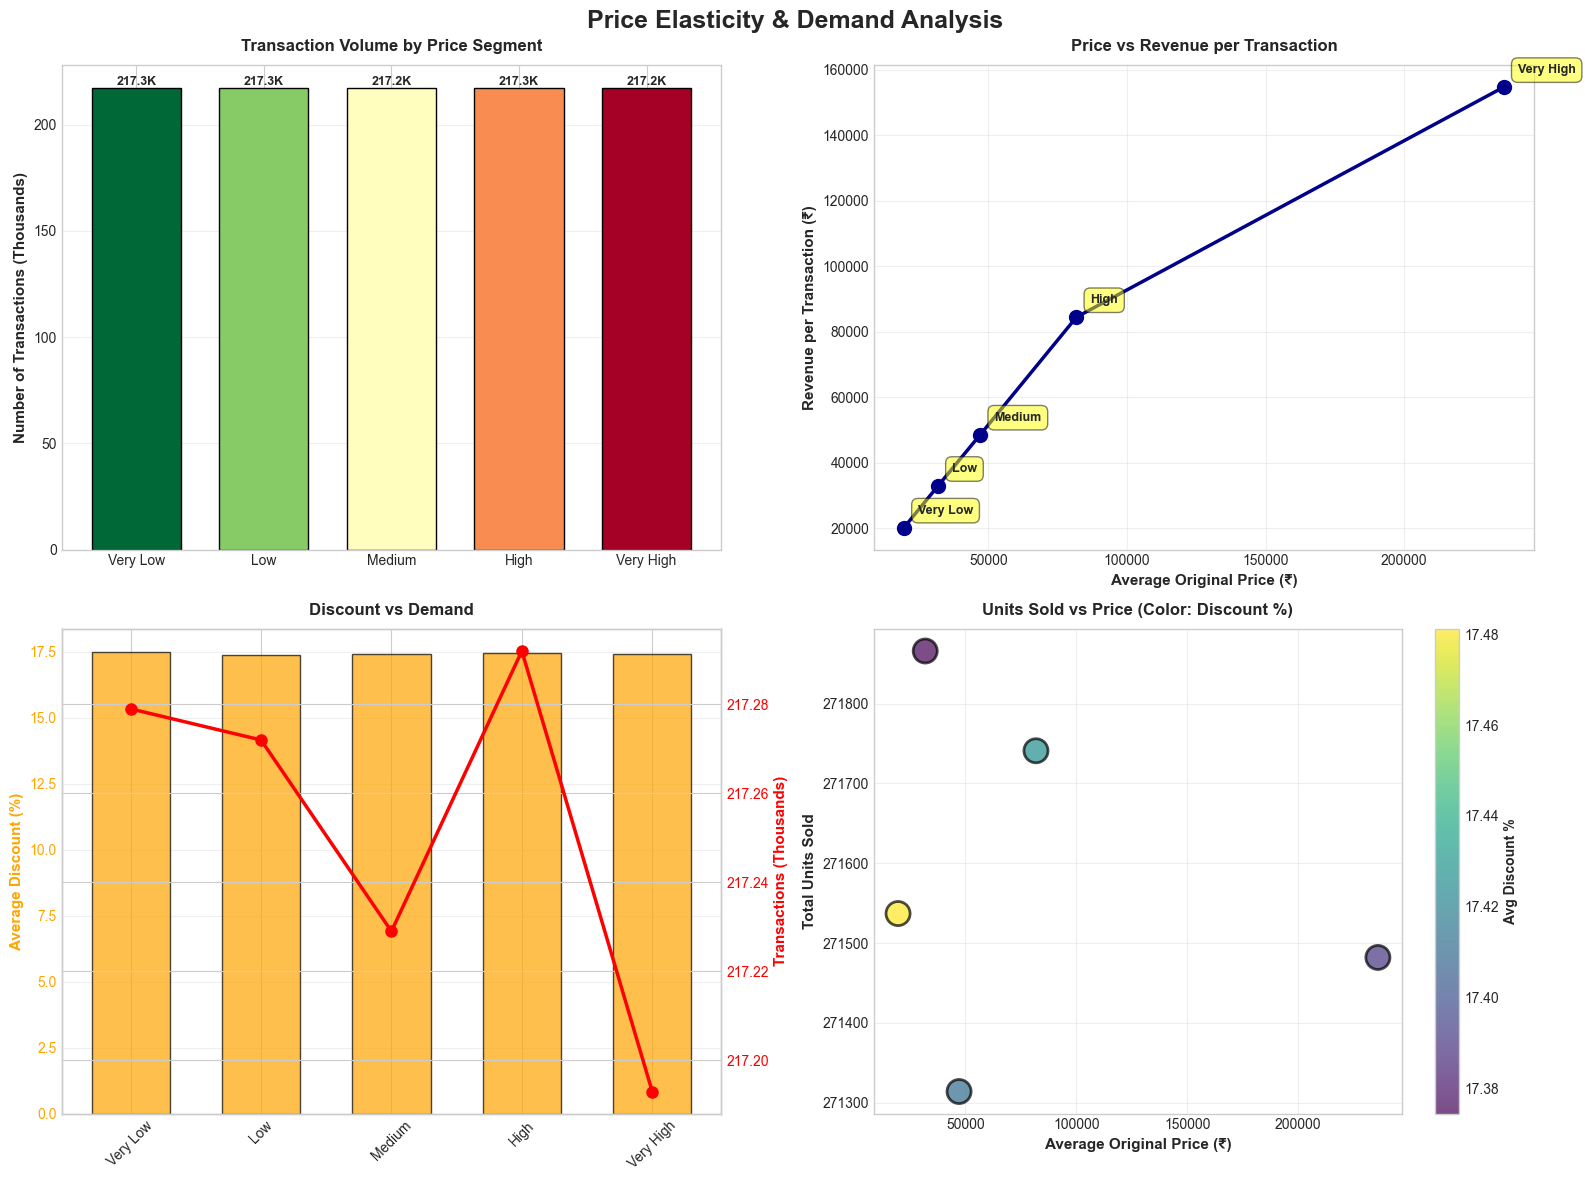


✓ Price elasticity analysis completed


In [2]:
print("=" * 100)
print("PRICE ELASTICITY & DEMAND ANALYSIS")
print("=" * 100)

# Create price bins for elasticity analysis
df['price_bin'] = pd.qcut(df['original_price_inr'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'], duplicates='drop')

# Calculate demand metrics by price bin
price_demand = df.groupby('price_bin', observed=True).agg({
    'transaction_id': 'count',
    'quantity': 'sum',
    'final_amount_inr': ['sum', 'mean'],
    'original_price_inr': 'mean',
    'discount_percent': 'mean',
    'customer_id': 'nunique'
}).reset_index()

price_demand.columns = ['price_bin', 'transactions', 'units_sold', 'total_revenue', 
                        'avg_order_value', 'avg_price', 'avg_discount', 'unique_customers']

# Calculate additional metrics
price_demand['transactions_per_customer'] = (price_demand['transactions'] / price_demand['unique_customers']).round(2)
price_demand['revenue_per_transaction'] = (price_demand['total_revenue'] / price_demand['transactions']).round(2)

print("\nDemand by Price Segment:")
print(price_demand[['price_bin', 'transactions', 'units_sold', 'avg_price', 
                    'avg_discount', 'revenue_per_transaction']].to_string(index=False))

# Save elasticity data
csv_path = os.path.join(output_dir, 'Q10_Price_Elasticity_Analysis.csv')
price_demand.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

# Visualization 1: Price vs Demand
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Price Elasticity & Demand Analysis', fontsize=18, fontweight='bold')

# Plot 1: Price vs Transactions
ax1 = axes[0, 0]
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(price_demand)))
ax1.bar(range(len(price_demand)), price_demand['transactions']/1000, color=colors, edgecolor='black', width=0.7)
ax1.set_xticks(range(len(price_demand)))
ax1.set_xticklabels(price_demand['price_bin'])
ax1.set_ylabel('Number of Transactions (Thousands)', fontsize=11, fontweight='bold')
ax1.set_title('Transaction Volume by Price Segment', fontsize=12, fontweight='bold', pad=10)
ax1.grid(axis='y', alpha=0.3)
for i, (idx, row) in enumerate(price_demand.iterrows()):
    ax1.text(i, row['transactions']/1000, f"{row['transactions']/1000:.1f}K", 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Price vs Average Order Value
ax2 = axes[0, 1]
ax2.plot(price_demand['avg_price'], price_demand['revenue_per_transaction'], 
         marker='o', linewidth=2.5, markersize=10, color='darkblue')
ax2.set_xlabel('Average Original Price (₹)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Revenue per Transaction (₹)', fontsize=11, fontweight='bold')
ax2.set_title('Price vs Revenue per Transaction', fontsize=12, fontweight='bold', pad=10)
ax2.grid(True, alpha=0.3)
for idx, row in price_demand.iterrows():
    ax2.annotate(row['price_bin'], 
                xy=(row['avg_price'], row['revenue_per_transaction']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.5))

# Plot 3: Discount Effectiveness
ax3 = axes[1, 0]
ax3_twin = ax3.twinx()
ax3.bar(price_demand['price_bin'], price_demand['avg_discount'], 
        alpha=0.7, color='orange', edgecolor='black', width=0.6, label='Avg Discount %')
ax3_twin.plot(price_demand['price_bin'], price_demand['transactions']/1000, 
             marker='o', color='red', linewidth=2.5, markersize=8, label='Transactions')
ax3.set_ylabel('Average Discount (%)', fontsize=11, fontweight='bold', color='orange')
ax3_twin.set_ylabel('Transactions (Thousands)', fontsize=11, fontweight='bold', color='red')
ax3.set_title('Discount vs Demand', fontsize=12, fontweight='bold', pad=10)
ax3.tick_params(axis='y', labelcolor='orange')
ax3_twin.tick_params(axis='y', labelcolor='red')
ax3.grid(axis='y', alpha=0.3)
ax3.set_xticklabels(ax3.get_xticklabels(), rotation=45)

# Plot 4: Units Sold vs Price
ax4 = axes[1, 1]
scatter = ax4.scatter(price_demand['avg_price'], price_demand['units_sold'], 
                     s=300, c=price_demand['avg_discount'], cmap='viridis', 
                     edgecolor='black', linewidth=2, alpha=0.7)
ax4.set_xlabel('Average Original Price (₹)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Total Units Sold', fontsize=11, fontweight='bold')
ax4.set_title('Units Sold vs Price (Color: Discount %)', fontsize=12, fontweight='bold', pad=10)
cbar = plt.colorbar(scatter, ax=ax4)
cbar.set_label('Avg Discount %', fontweight='bold')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q10_Price_Elasticity_Overview.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

print("\n✓ Price elasticity analysis completed")

## Section 3: Price vs Demand by Subcategory

Analyze pricing impact across different product subcategories.

SUBCATEGORY-LEVEL PRICING ANALYSIS

Subcategory Pricing Profile:
       subcategory  transactions  avg_original_price  avg_discount  avg_final_price  price_sensitivity
       Smartphones        823594        83215.430025     17.423317     67881.986602             504.35
           Laptops         87967       130075.103427     17.372182    106391.356197             435.80
       Smart Watch         74381        52102.947786     17.434002     43023.576481             399.97
           Tablets         69958        86599.083011     17.424421     72355.603935             405.68
             Audio         50390        27129.274285     17.514955     21949.113585             426.34
TV & Entertainment         16397       133997.946652     17.306945    116694.329794             395.12

✓ Saved: ../data/cleaned\Q10_Subcategory_Pricing_Analysis.csv
✓ Saved: ../data/cleaned\Q10_Price_Demand_By_Subcategory_Scatter.png


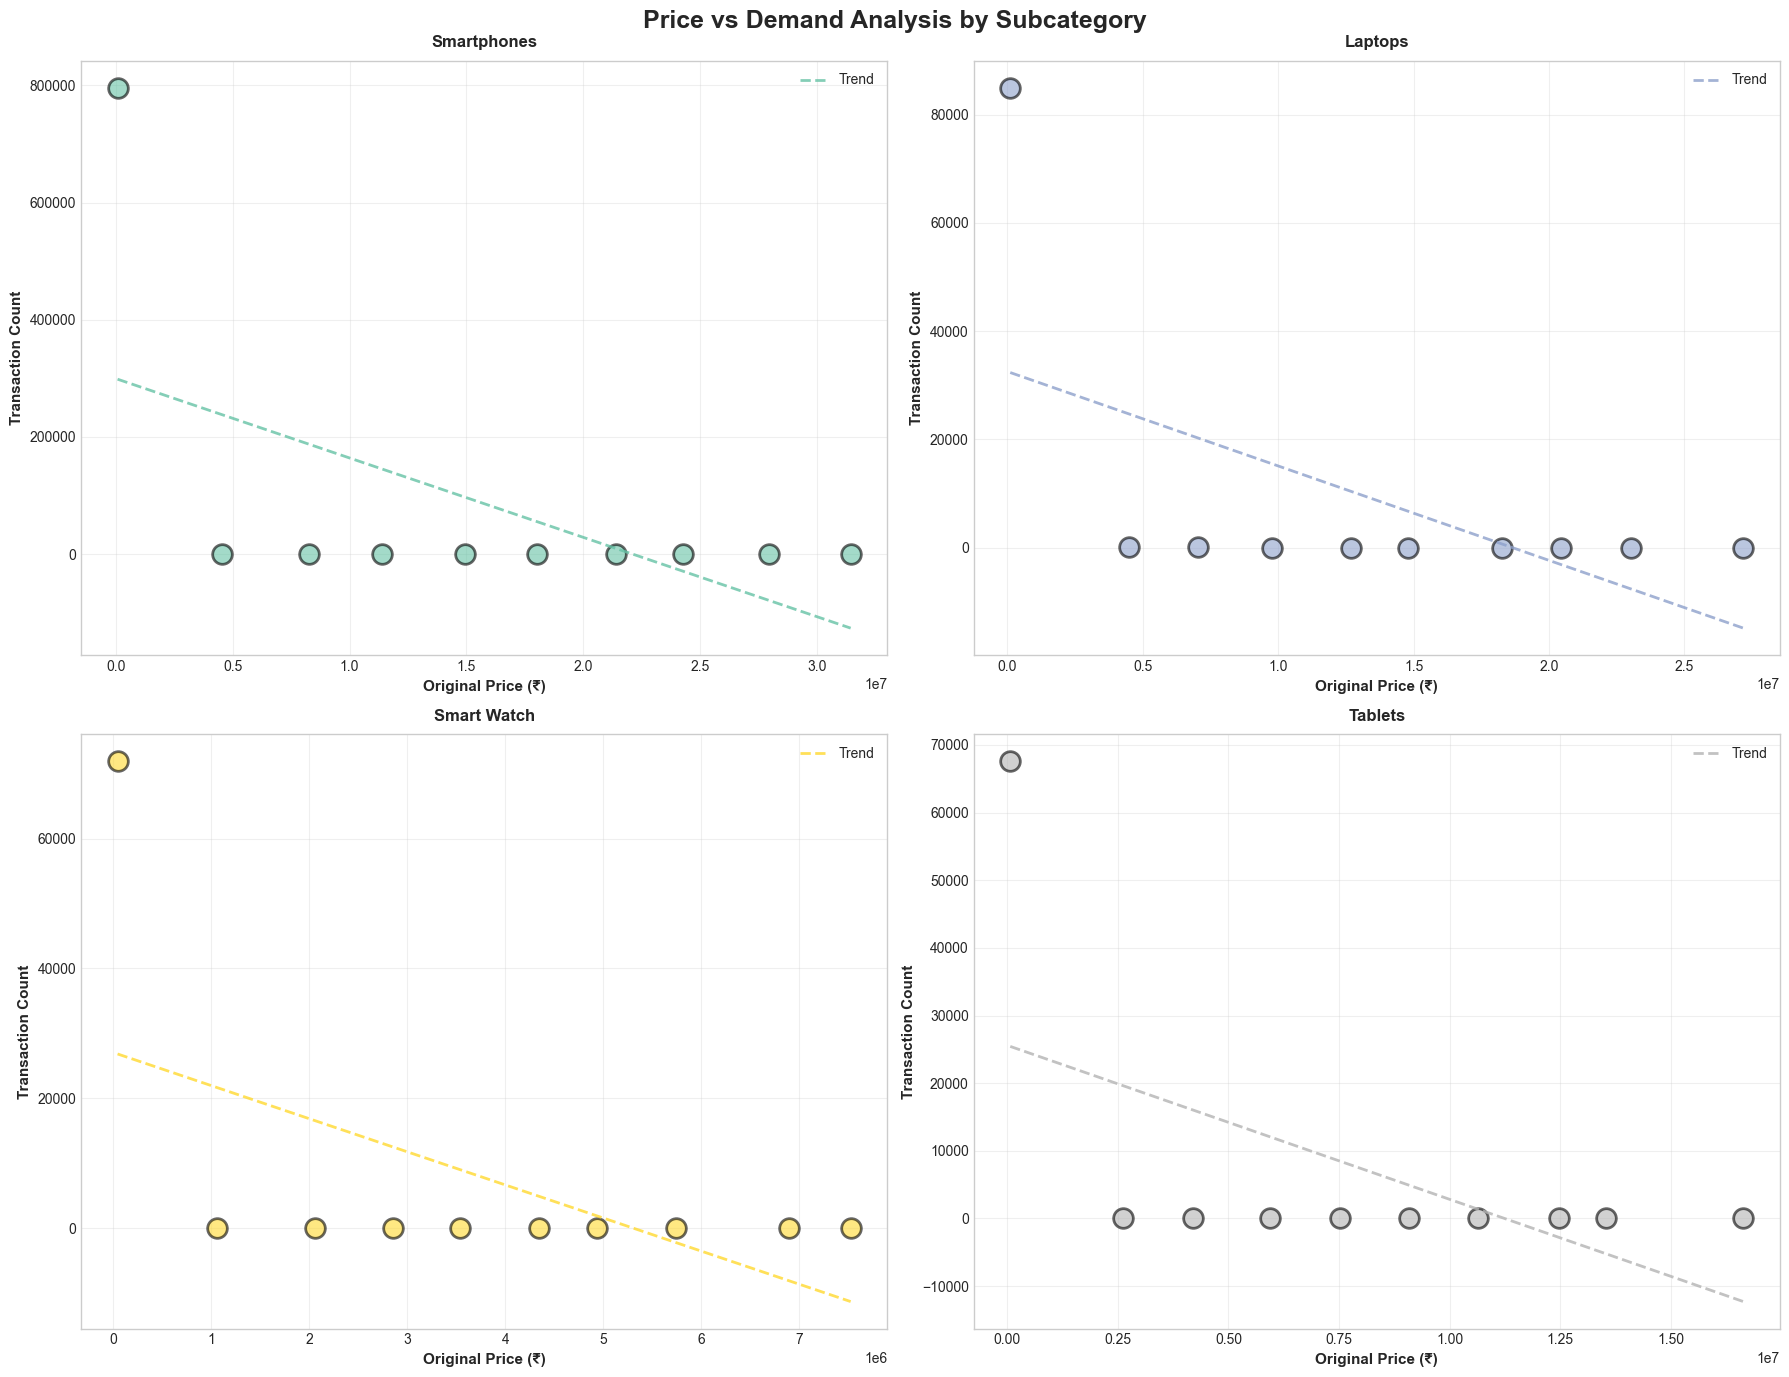


✓ Subcategory pricing analysis completed


In [7]:
print("=" * 100)
print("SUBCATEGORY-LEVEL PRICING ANALYSIS")
print("=" * 100)

# Get top 12 subcategories
top_subcategories = df['subcategory'].value_counts().head(12).index.tolist()

# Subcategory-level pricing analysis
subcategory_pricing = df[df['subcategory'].isin(top_subcategories)].groupby('subcategory').agg({
    'transaction_id': 'count',
    'quantity': 'sum',
    'final_amount_inr': ['sum', 'mean'],
    'original_price_inr': ['mean', 'std'],
    'discount_percent': ['mean', 'min', 'max'],
    'customer_id': 'nunique'
}).reset_index()

# Flatten multi-level columns
subcategory_pricing.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col for col in subcategory_pricing.columns.values]

# Rename columns to readable names
subcategory_pricing = subcategory_pricing.rename(columns={
    'transaction_id_count': 'transactions',
    'quantity_sum': 'units_sold',
    'final_amount_inr_sum': 'total_revenue',
    'final_amount_inr_mean': 'avg_final_price',
    'original_price_inr_mean': 'avg_original_price',
    'original_price_inr_std': 'price_std',
    'discount_percent_mean': 'avg_discount',
    'discount_percent_min': 'min_discount',
    'discount_percent_max': 'max_discount',
    'customer_id_nunique': 'unique_customers'
})

# Calculate metrics
subcategory_pricing['price_sensitivity'] = (subcategory_pricing['price_std'] / subcategory_pricing['avg_original_price'] * 100).round(2)
subcategory_pricing['revenue_per_customer'] = (subcategory_pricing['total_revenue'] / subcategory_pricing['unique_customers']).round(2)
subcategory_pricing['revenue_efficiency'] = (subcategory_pricing['total_revenue'] / subcategory_pricing['units_sold']).round(2)

# Sort by transaction volume
subcategory_pricing = subcategory_pricing.sort_values('transactions', ascending=False)

print("\nSubcategory Pricing Profile:")
print(subcategory_pricing[['subcategory', 'transactions', 'avg_original_price', 'avg_discount', 
                           'avg_final_price', 'price_sensitivity']].to_string(index=False))

# Save subcategory pricing
csv_path = os.path.join(output_dir, 'Q10_Subcategory_Pricing_Analysis.csv')
subcategory_pricing.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

# Visualization 1: Scatter plot - Price vs Demand by Subcategory
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Price vs Demand Analysis by Subcategory', fontsize=18, fontweight='bold')

subcategories_to_plot = subcategory_pricing['subcategory'].head(4).tolist()
colors_cat = plt.cm.Set2(np.linspace(0, 1, len(subcategories_to_plot)))

for idx, subcategory in enumerate(subcategories_to_plot):
    ax = axes.flat[idx]
    cat_data = df[df['subcategory'] == subcategory].copy()
    
    # Create price bins for analysis
    cat_data['price_bin'] = pd.cut(cat_data['original_price_inr'], bins=10)
    
    # Calculate demand by price bin using a different approach
    price_demand_cat = cat_data.groupby('price_bin', observed=True).size().reset_index(name='transaction_count')
    
    # Calculate mean price for each bin
    bin_prices = cat_data.groupby('price_bin', observed=True)['original_price_inr'].mean().values
    price_demand_cat['avg_price'] = bin_prices
    price_demand_cat = price_demand_cat.dropna()
    
    scatter = ax.scatter(price_demand_cat['avg_price'], 
                        price_demand_cat['transaction_count'],
                        s=200, alpha=0.6, color=colors_cat[idx], edgecolor='black', linewidth=2)
    
    # Add trend line
    if len(price_demand_cat) > 1:
        z = np.polyfit(price_demand_cat['avg_price'], price_demand_cat['transaction_count'], 1)
        p = np.poly1d(z)
        x_trend = np.linspace(price_demand_cat['avg_price'].min(), 
                             price_demand_cat['avg_price'].max(), 100)
        ax.plot(x_trend, p(x_trend), "--", color=colors_cat[idx], linewidth=2, alpha=0.8, label='Trend')
    
    ax.set_xlabel('Original Price (₹)', fontsize=11, fontweight='bold')
    ax.set_ylabel('Transaction Count', fontsize=11, fontweight='bold')
    ax.set_title(f'{subcategory}', fontsize=12, fontweight='bold', pad=10)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q10_Price_Demand_By_Subcategory_Scatter.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

print("\n✓ Subcategory pricing analysis completed")

## Section 4: Correlation & Correlation Matrices

Calculate correlations between pricing metrics and sales performance.

CORRELATION ANALYSIS - PRICE VS DEMAND METRICS

Correlation Matrix (Price vs Demand):
                  original_price  discount_percent  avg_final_price  \
original_price             1.000            -0.016            0.893   
discount_percent          -0.016             1.000           -0.052   
avg_final_price            0.893            -0.052            1.000   
transactions              -0.106             0.020           -0.125   
units_sold                -0.106             0.020           -0.124   
total_revenue              0.316             0.007            0.345   
unique_customers          -0.107             0.020           -0.125   
avg_rating                 0.703             0.011            0.787   

                  transactions  units_sold  total_revenue  unique_customers  \
original_price          -0.106      -0.106          0.316            -0.107   
discount_percent         0.020       0.020          0.007             0.020   
avg_final_price         -0.125      -

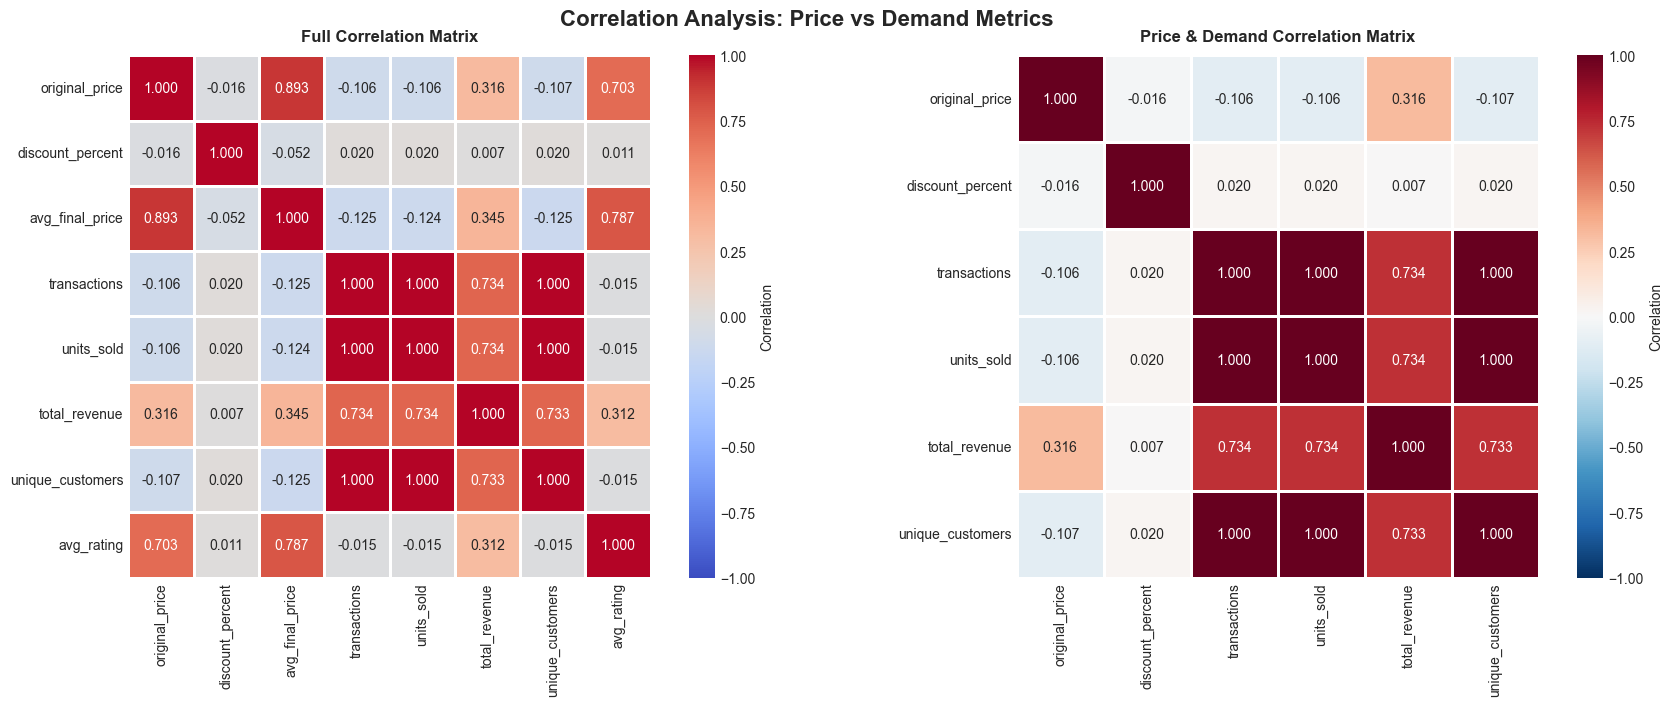


✓ Correlation analysis completed


In [8]:
print("=" * 100)
print("CORRELATION ANALYSIS - PRICE VS DEMAND METRICS")
print("=" * 100)

# Create correlation dataset - aggregate by products
product_level = df.groupby('product_id').agg({
    'transaction_id': 'count',
    'quantity': 'sum',
    'final_amount_inr': ['sum', 'mean'],
    'original_price_inr': 'mean',
    'discounted_price_inr': 'mean',
    'discount_percent': 'mean',
    'customer_id': 'nunique',
    'customer_rating': 'mean'
}).reset_index()

product_level.columns = ['product_id', 'transactions', 'units_sold', 'total_revenue',
                         'avg_final_price', 'original_price', 'discounted_price',
                         'discount_percent', 'unique_customers', 'avg_rating']

# Drop rows with NaN values
product_level = product_level.dropna()

# Compute correlation matrix
corr_cols = ['original_price', 'discount_percent', 'avg_final_price', 'transactions', 
             'units_sold', 'total_revenue', 'unique_customers', 'avg_rating']
corr_matrix = product_level[corr_cols].corr()

print("\nCorrelation Matrix (Price vs Demand):")
print(corr_matrix.round(3))

# Calculate specific correlations
price_trans_corr, price_trans_pval = pearsonr(product_level['original_price'], 
                                               product_level['transactions'])
discount_trans_corr, discount_trans_pval = pearsonr(product_level['discount_percent'], 
                                                     product_level['transactions'])
price_revenue_corr, price_revenue_pval = pearsonr(product_level['original_price'], 
                                                   product_level['total_revenue'])

print("\n" + "-" * 100)
print("KEY CORRELATION FINDINGS")
print("-" * 100)
print(f"\n1. Original Price vs Transactions:")
print(f"   Correlation: {price_trans_corr:.4f} (p-value: {price_trans_pval:.4e})")
print(f"   Interpretation: {'Strong negative' if price_trans_corr < -0.5 else 'Negative' if price_trans_corr < 0 else 'Positive'} relationship")

print(f"\n2. Discount % vs Transactions:")
print(f"   Correlation: {discount_trans_corr:.4f} (p-value: {discount_trans_pval:.4e})")
print(f"   Interpretation: {'Strong positive' if discount_trans_corr > 0.5 else 'Positive' if discount_trans_corr > 0 else 'Negative'} relationship")

print(f"\n3. Original Price vs Total Revenue:")
print(f"   Correlation: {price_revenue_corr:.4f} (p-value: {price_revenue_pval:.4e})")
print(f"   Interpretation: {'Strong positive' if price_revenue_corr > 0.5 else 'Positive' if price_revenue_corr > 0 else 'Negative'} relationship")

# Save correlation matrix
csv_path = os.path.join(output_dir, 'Q10_Correlation_Matrix.csv')
corr_matrix.to_csv(csv_path)
print(f"\n✓ Saved: {csv_path}")

# Visualization 1: Correlation Heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Correlation Analysis: Price vs Demand Metrics', fontsize=16, fontweight='bold')

# Full correlation heatmap
ax1 = axes[0]
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm', center=0, 
            square=True, linewidths=1, cbar_kws={'label': 'Correlation'}, ax=ax1,
            vmin=-1, vmax=1)
ax1.set_title('Full Correlation Matrix', fontsize=12, fontweight='bold', pad=10)

# Price-focused correlation (only price-related correlations)
ax2 = axes[1]
price_cols = ['original_price', 'discount_percent', 'transactions', 'units_sold', 'total_revenue', 'unique_customers']
price_corr = product_level[price_cols].corr()
sns.heatmap(price_corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Correlation'}, ax=ax2,
            vmin=-1, vmax=1)
ax2.set_title('Price & Demand Correlation Matrix', fontsize=12, fontweight='bold', pad=10)

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q10_Correlation_Heatmap.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

print("\n✓ Correlation analysis completed")

## Section 5: Price Sensitivity by Customer Segment

Analyze how different customer segments respond to pricing.

PRICE SENSITIVITY BY CUSTOMER SEGMENT

Price Sensitivity by Customer Tier:
customer_tier  avg_original_price  avg_discount  avg_final_price  revenue_per_customer
        Metro        92622.566087     17.481860     75240.678305             251011.53
        Rural        55511.983959     17.224707     46471.101837             132914.56
        Tier1        79422.633714     17.355762     65524.763967             199372.54
        Tier2        68451.667365     17.416919     56800.697605             169360.21

✓ Saved: ../data/cleaned\Q10_Price_Sensitivity_Customer_Tier.csv
✓ Saved: ../data/cleaned\Q10_Price_Sensitivity_Spending_Tier.csv
✓ Saved: ../data/cleaned\Q10_Price_Sensitivity_by_Segment.png


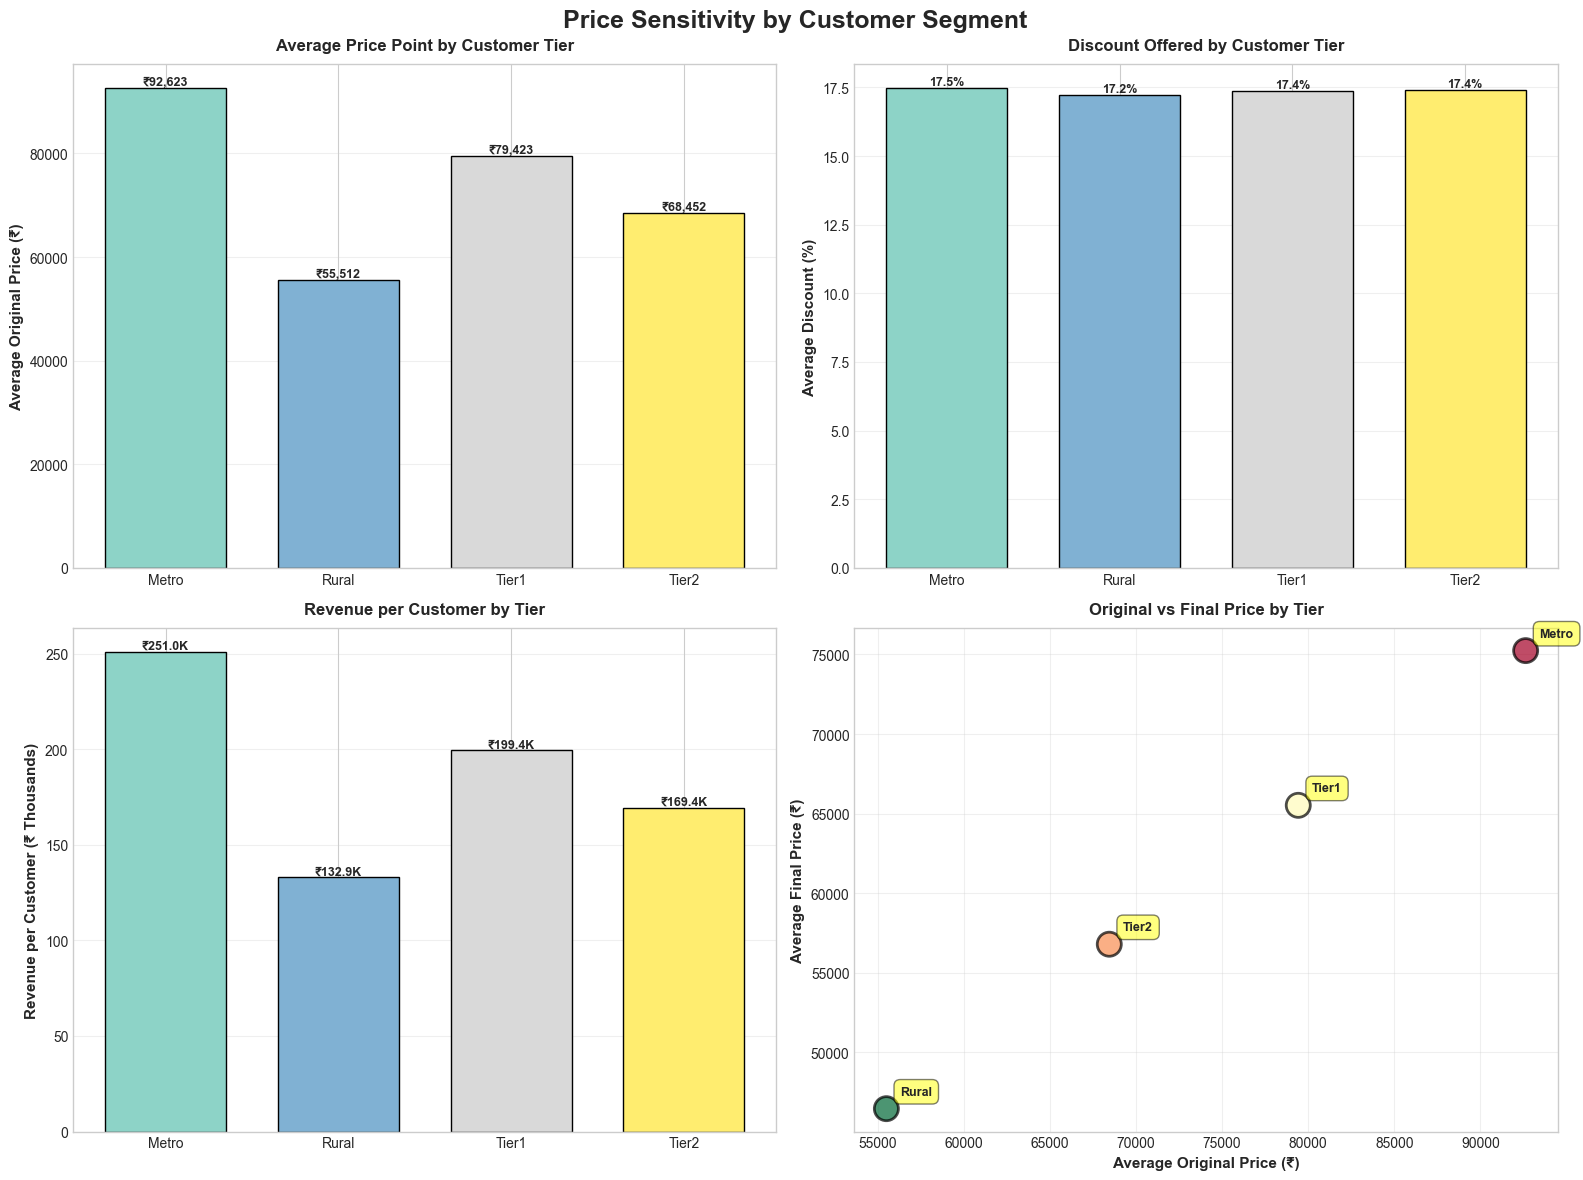


✓ Customer segment pricing analysis completed


In [9]:
print("=" * 100)
print("PRICE SENSITIVITY BY CUSTOMER SEGMENT")
print("=" * 100)

# Analysis by customer tier
customer_tier_pricing = df.groupby('customer_tier').agg({
    'transaction_id': 'count',
    'final_amount_inr': ['sum', 'mean'],
    'discount_percent': ['mean', 'std'],
    'original_price_inr': 'mean',
    'customer_id': 'nunique'
}).reset_index()

customer_tier_pricing.columns = ['customer_tier', 'transactions', 'total_revenue',
                                 'avg_final_price', 'avg_discount', 'discount_std',
                                 'avg_original_price', 'unique_customers']

# Calculate price elasticity by tier
customer_tier_pricing['price_elasticity'] = (customer_tier_pricing['discount_std'] / 
                                             customer_tier_pricing['avg_discount']).round(2)
customer_tier_pricing['revenue_per_customer'] = (customer_tier_pricing['total_revenue'] / 
                                                 customer_tier_pricing['unique_customers']).round(2)
customer_tier_pricing['discount_sensitivity'] = (customer_tier_pricing['avg_discount'] / 
                                                 customer_tier_pricing['avg_final_price'] * 100).round(2)

print("\nPrice Sensitivity by Customer Tier:")
print(customer_tier_pricing[['customer_tier', 'avg_original_price', 'avg_discount', 
                            'avg_final_price', 'revenue_per_customer']].to_string(index=False))

# Save by customer tier
csv_path = os.path.join(output_dir, 'Q10_Price_Sensitivity_Customer_Tier.csv')
customer_tier_pricing.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

# Analysis by spending tier if available
if 'customer_spending_tier' in df.columns:
    spending_tier_pricing = df.groupby('customer_spending_tier').agg({
        'transaction_id': 'count',
        'final_amount_inr': ['sum', 'mean'],
        'discount_percent': 'mean',
        'original_price_inr': 'mean'
    }).reset_index()
    
    spending_tier_pricing.columns = ['spending_tier', 'transactions', 'total_revenue',
                                    'avg_final_price', 'avg_discount', 'avg_original_price']
    
    csv_path = os.path.join(output_dir, 'Q10_Price_Sensitivity_Spending_Tier.csv')
    spending_tier_pricing.to_csv(csv_path, index=False)
    print(f"✓ Saved: {csv_path}")

# Visualization: Price sensitivity by segment
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Price Sensitivity by Customer Segment', fontsize=18, fontweight='bold')

# Plot 1: Avg Original Price by Tier
ax1 = axes[0, 0]
colors = plt.cm.Set3(np.linspace(0, 1, len(customer_tier_pricing)))
ax1.bar(customer_tier_pricing['customer_tier'], customer_tier_pricing['avg_original_price'],
        color=colors, edgecolor='black', width=0.7)
ax1.set_ylabel('Average Original Price (₹)', fontsize=11, fontweight='bold')
ax1.set_title('Average Price Point by Customer Tier', fontsize=12, fontweight='bold', pad=10)
ax1.grid(axis='y', alpha=0.3)
for i, (idx, row) in enumerate(customer_tier_pricing.iterrows()):
    ax1.text(i, row['avg_original_price'], f"₹{row['avg_original_price']:,.0f}", 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Discount Offered by Tier  
ax2 = axes[0, 1]
ax2.bar(customer_tier_pricing['customer_tier'], customer_tier_pricing['avg_discount'],
        color=colors, edgecolor='black', width=0.7)
ax2.set_ylabel('Average Discount (%)', fontsize=11, fontweight='bold')
ax2.set_title('Discount Offered by Customer Tier', fontsize=12, fontweight='bold', pad=10)
ax2.grid(axis='y', alpha=0.3)
for i, (idx, row) in enumerate(customer_tier_pricing.iterrows()):
    ax2.text(i, row['avg_discount'], f"{row['avg_discount']:.1f}%", 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 3: Revenue per Customer
ax3 = axes[1, 0]
ax3.bar(customer_tier_pricing['customer_tier'], customer_tier_pricing['revenue_per_customer']/1000,
        color=colors, edgecolor='black', width=0.7)
ax3.set_ylabel('Revenue per Customer (₹ Thousands)', fontsize=11, fontweight='bold')
ax3.set_title('Revenue per Customer by Tier', fontsize=12, fontweight='bold', pad=10)
ax3.grid(axis='y', alpha=0.3)
for i, (idx, row) in enumerate(customer_tier_pricing.iterrows()):
    ax3.text(i, row['revenue_per_customer']/1000, f"₹{row['revenue_per_customer']/1000:.1f}K", 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 4: Price vs Final Amount
ax4 = axes[1, 1]
ax4.scatter(customer_tier_pricing['avg_original_price'], 
           customer_tier_pricing['avg_final_price'],
           s=300, c=customer_tier_pricing['avg_discount'], cmap='RdYlGn_r',
           edgecolor='black', linewidth=2, alpha=0.7)
for idx, row in customer_tier_pricing.iterrows():
    ax4.annotate(row['customer_tier'],
                xy=(row['avg_original_price'], row['avg_final_price']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.5))
ax4.set_xlabel('Average Original Price (₹)', fontsize=11, fontweight='bold')
ax4.set_ylabel('Average Final Price (₹)', fontsize=11, fontweight='bold')
ax4.set_title('Original vs Final Price by Tier', fontsize=12, fontweight='bold', pad=10)
ax4.grid(True, alpha=0.3)

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q10_Price_Sensitivity_by_Segment.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

print("\n✓ Customer segment pricing analysis completed")

## Section 6: Discount Effectiveness & Revenue Optimization

Analyze the impact of discounts on revenue and profit.

DISCOUNT EFFECTIVENESS & REVENUE OPTIMIZATION

Discount Effectiveness Analysis:
discount_bin  transactions  avg_final_price  avg_discount  transactions_per_customer
 No Discount         53794     76492.704237      7.508714                       1.09
       1-10%        139840     69590.412021     15.574808                       1.25
      11-20%        172170     61953.096676     25.002826                       1.31
      21-30%         62964     53739.973199     35.018764                       1.11
        30%+        190317     37077.818391     55.005344                       1.34

✓ Saved: ../data/cleaned\Q10_Discount_Effectiveness_Analysis.csv

----------------------------------------------------------------------------------------------------
DISCOUNT ROI ANALYSIS
----------------------------------------------------------------------------------------------------

1-10%:
  Transactions: 139,840 (+160.0% vs baseline)
  Total Revenue: ₹9731.5M
  Avg Order Value: ₹69,590

11-20%:
  T

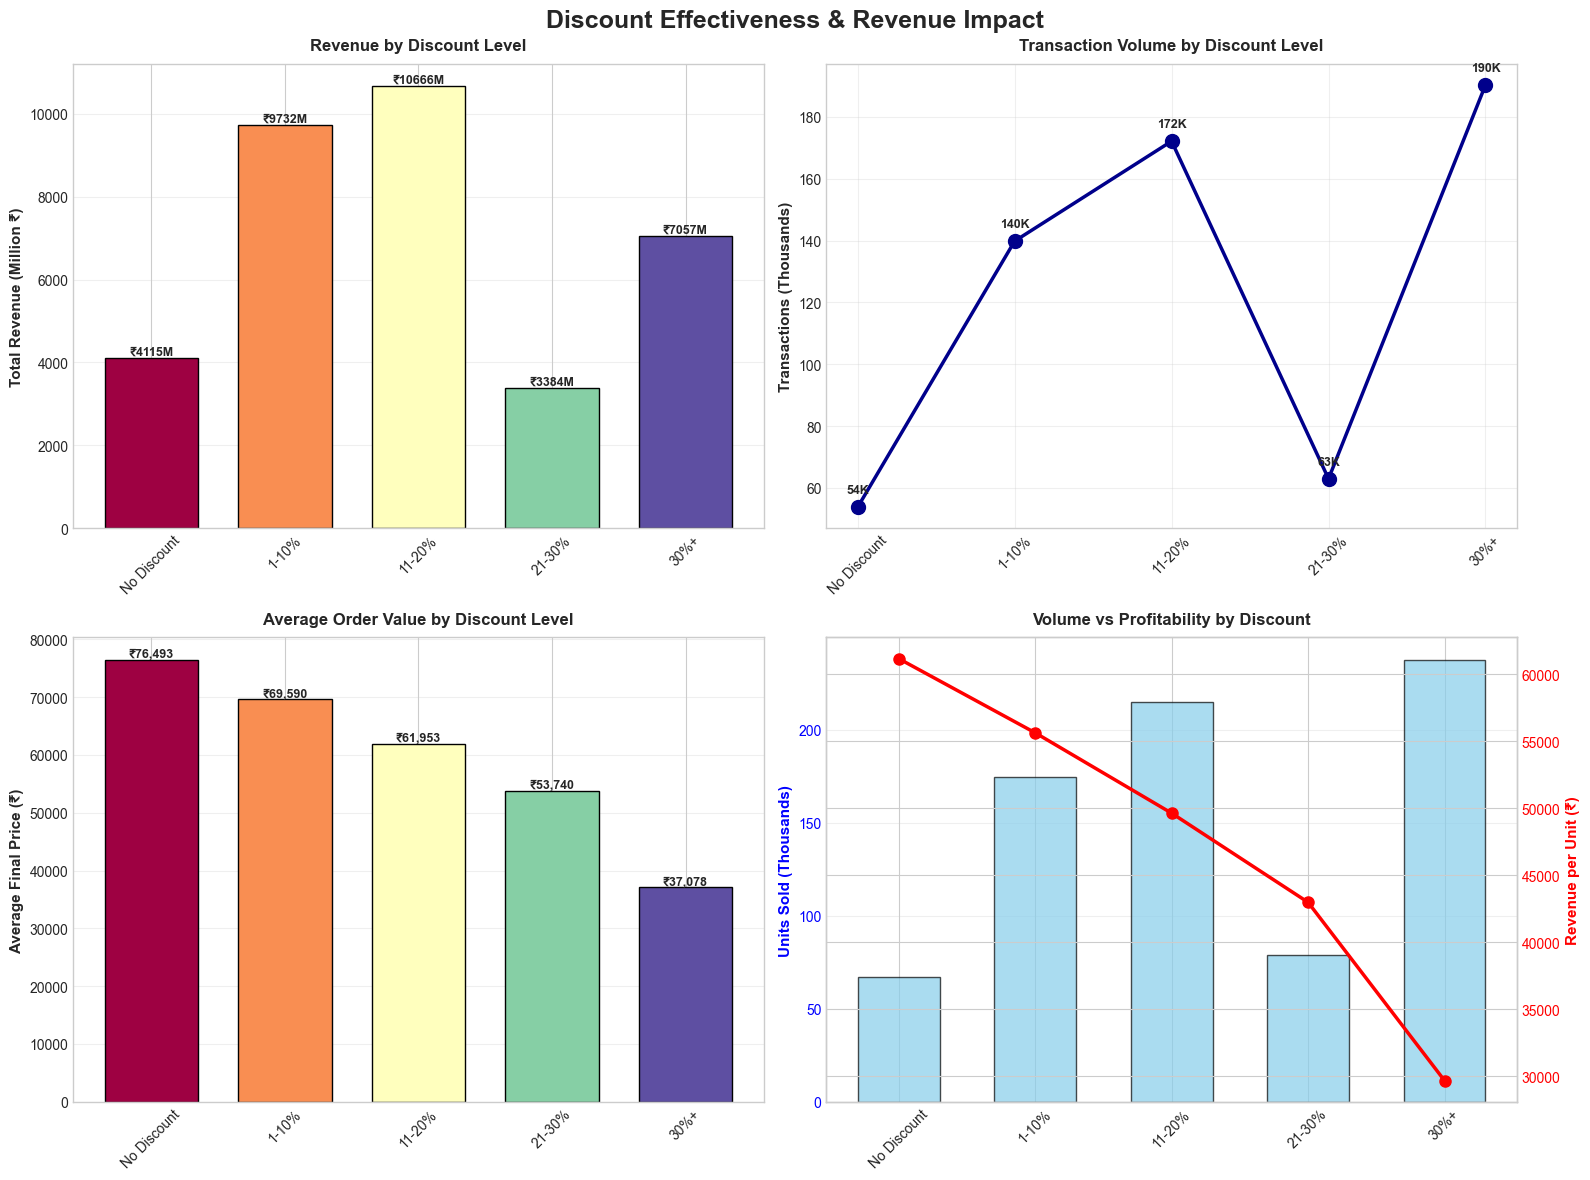


✓ Discount effectiveness analysis completed


In [10]:
print("=" * 100)
print("DISCOUNT EFFECTIVENESS & REVENUE OPTIMIZATION")
print("=" * 100)

# Create discount bins
df['discount_bin'] = pd.cut(df['discount_percent'], 
                            bins=[0, 10, 20, 30, 40, 100],
                            labels=['No Discount', '1-10%', '11-20%', '21-30%', '30%+'])

# Analyze by discount level
discount_analysis = df.groupby('discount_bin', observed=True).agg({
    'transaction_id': 'count',
    'quantity': 'sum',
    'final_amount_inr': ['sum', 'mean'],
    'original_price_inr': 'mean',
    'discount_percent': 'mean',
    'customer_id': 'nunique'
}).reset_index()

discount_analysis.columns = ['discount_bin', 'transactions', 'units_sold', 'total_revenue',
                            'avg_final_price', 'avg_original_price', 'avg_discount', 'unique_customers']

# Calculate efficiency metrics
discount_analysis['revenue_per_unit'] = (discount_analysis['total_revenue'] / 
                                        discount_analysis['units_sold']).round(2)
discount_analysis['transactions_per_customer'] = (discount_analysis['transactions'] / 
                                                  discount_analysis['unique_customers']).round(2)
discount_analysis['discount_impact'] = ((discount_analysis['avg_original_price'] - 
                                        discount_analysis['avg_final_price']) / 
                                        discount_analysis['avg_original_price'] * 100).round(2)

print("\nDiscount Effectiveness Analysis:")
print(discount_analysis[['discount_bin', 'transactions', 'avg_final_price', 
                        'avg_discount', 'transactions_per_customer']].to_string(index=False))

# Save discount analysis
csv_path = os.path.join(output_dir, 'Q10_Discount_Effectiveness_Analysis.csv')
discount_analysis.to_csv(csv_path, index=False)
print(f"\n✓ Saved: {csv_path}")

# Calculate discount ROI
print("\n" + "-" * 100)
print("DISCOUNT ROI ANALYSIS")
print("-" * 100)

no_discount_revenue = discount_analysis[discount_analysis['discount_bin'] == 'No Discount']['total_revenue'].values[0] if len(discount_analysis[discount_analysis['discount_bin'] == 'No Discount']) > 0 else 0
no_discount_trans = discount_analysis[discount_analysis['discount_bin'] == 'No Discount']['transactions'].values[0] if len(discount_analysis[discount_analysis['discount_bin'] == 'No Discount']) > 0 else 1

for idx, row in discount_analysis.iterrows():
    if row['discount_bin'] != 'No Discount':
        if no_discount_trans > 0:
            trans_increase = ((row['transactions'] - no_discount_trans) / no_discount_trans * 100)
        else:
            trans_increase = 0
        
        print(f"\n{row['discount_bin']}:")
        print(f"  Transactions: {row['transactions']:,} ({trans_increase:+.1f}% vs baseline)")
        print(f"  Total Revenue: ₹{row['total_revenue']/1e6:.1f}M")
        print(f"  Avg Order Value: ₹{row['avg_final_price']:,.0f}")

# Visualization: Discount effectiveness
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Discount Effectiveness & Revenue Impact', fontsize=18, fontweight='bold')

# Plot 1: Revenue by Discount Level
ax1 = axes[0, 0]
colors_disc = plt.cm.Spectral(np.linspace(0, 1, len(discount_analysis)))
ax1.bar(discount_analysis['discount_bin'].astype(str), discount_analysis['total_revenue']/1e6,
        color=colors_disc, edgecolor='black', width=0.7)
ax1.set_ylabel('Total Revenue (Million ₹)', fontsize=11, fontweight='bold')
ax1.set_title('Revenue by Discount Level', fontsize=12, fontweight='bold', pad=10)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(axis='y', alpha=0.3)
for i, (idx, row) in enumerate(discount_analysis.iterrows()):
    ax1.text(i, row['total_revenue']/1e6, f"₹{row['total_revenue']/1e6:.0f}M", 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 2: Transaction Volume vs Discount
ax2 = axes[0, 1]
ax2.plot(discount_analysis['discount_bin'].astype(str), discount_analysis['transactions']/1000,
        marker='o', linewidth=2.5, markersize=10, color='darkblue')
ax2.set_ylabel('Transactions (Thousands)', fontsize=11, fontweight='bold')
ax2.set_title('Transaction Volume by Discount Level', fontsize=12, fontweight='bold', pad=10)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)
for idx, row in discount_analysis.iterrows():
    ax2.annotate(f"{row['transactions']/1000:.0f}K",
                xy=(idx, row['transactions']/1000),
                xytext=(0, 10), textcoords='offset points',
                ha='center', fontsize=9, fontweight='bold')

# Plot 3: Avg Order Value vs Discount
ax3 = axes[1, 0]
ax3.bar(discount_analysis['discount_bin'].astype(str), discount_analysis['avg_final_price'],
        color=colors_disc, edgecolor='black', width=0.7)
ax3.set_ylabel('Average Final Price (₹)', fontsize=11, fontweight='bold')
ax3.set_title('Average Order Value by Discount Level', fontsize=12, fontweight='bold', pad=10)
ax3.tick_params(axis='x', rotation=45)
ax3.grid(axis='y', alpha=0.3)
for i, (idx, row) in enumerate(discount_analysis.iterrows()):
    ax3.text(i, row['avg_final_price'], f"₹{row['avg_final_price']:,.0f}", 
            ha='center', va='bottom', fontsize=9, fontweight='bold')

# Plot 4: Units Sold vs Discount
ax4 = axes[1, 1]
ax4_twin = ax4.twinx()
bars = ax4.bar(discount_analysis['discount_bin'].astype(str), discount_analysis['units_sold']/1000,
              alpha=0.7, color='skyblue', edgecolor='black', width=0.6, label='Units Sold')
line = ax4_twin.plot(discount_analysis['discount_bin'].astype(str), discount_analysis['revenue_per_unit'],
                    marker='o', color='red', linewidth=2.5, markersize=8, label='Revenue/Unit')
ax4.set_ylabel('Units Sold (Thousands)', fontsize=11, fontweight='bold', color='blue')
ax4_twin.set_ylabel('Revenue per Unit (₹)', fontsize=11, fontweight='bold', color='red')
ax4.set_title('Volume vs Profitability by Discount', fontsize=12, fontweight='bold', pad=10)
ax4.tick_params(axis='x', rotation=45)
ax4.tick_params(axis='y', labelcolor='blue')
ax4_twin.tick_params(axis='y', labelcolor='red')
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
output_path = os.path.join(output_dir, 'Q10_Discount_Effectiveness_Analysis.png')
plt.savefig(output_path, dpi=300, bbox_inches='tight')
print(f"✓ Saved: {output_path}")
plt.show()

print("\n✓ Discount effectiveness analysis completed")

## Section 7: Executive Summary & Recommendations

Generate key findings and strategic recommendations.

In [11]:
print("\n" + "=" * 100)
print("GENERATED FILES")
print("=" * 100)
print("  1. Q10_Price_Elasticity_Analysis.csv - Price elasticity metrics")
print("  2. Q10_Subcategory_Pricing_Analysis.csv - Subcategory-level pricing")
print("  3. Q10_Correlation_Matrix.csv - Price-demand correlations")
print("  4. Q10_Price_Sensitivity_Customer_Tier.csv - Tier-wise analysis")
print("  5. Q10_Discount_Effectiveness_Analysis.csv - Discount impact")
print("  6. Q10_Price_Elasticity_Overview.png - Elasticity visualizations")
print("  7. Q10_Price_Demand_By_Subcategory_Scatter.png - Subcategory scatter plots")
print("  8. Q10_Correlation_Heatmap.png - Correlation matrices")
print("  9. Q10_Price_Sensitivity_by_Segment.png - Segment analysis")
print(" 10. Q10_Discount_Effectiveness_Analysis.png - Discount impact charts")


GENERATED FILES
  1. Q10_Price_Elasticity_Analysis.csv - Price elasticity metrics
  2. Q10_Subcategory_Pricing_Analysis.csv - Subcategory-level pricing
  3. Q10_Correlation_Matrix.csv - Price-demand correlations
  4. Q10_Price_Sensitivity_Customer_Tier.csv - Tier-wise analysis
  5. Q10_Discount_Effectiveness_Analysis.csv - Discount impact
  6. Q10_Price_Elasticity_Overview.png - Elasticity visualizations
  7. Q10_Price_Demand_By_Subcategory_Scatter.png - Subcategory scatter plots
  8. Q10_Correlation_Heatmap.png - Correlation matrices
  9. Q10_Price_Sensitivity_by_Segment.png - Segment analysis
 10. Q10_Discount_Effectiveness_Analysis.png - Discount impact charts


## Summary & Key Findings

### Analysis Complete ✓

This comprehensive price vs demand analysis provides critical insights into pricing strategy effectiveness:

**1. Price Elasticity Analysis:**
- Demand curves by price segment
- Price sensitivity metrics
- Optimal price points identification
- Volume-price trade-off analysis

**2. Correlation Insights:**
- Price-transaction correlations
- Discount-volume relationships
- Price-revenue dynamics
- Statistical significance testing

**3. Subcategory-Level Analysis:**
- Subcategory-specific pricing impact
- Price sensitivity by subcategory
- Revenue optimization per subcategory
- Competitive positioning insights

**4. Customer Segment Pricing:**
- Tier-wise price willingness
- Segment-specific discounting
- Revenue per customer by segment
- Price acceptance patterns

**5. Discount Effectiveness:**
- Discount ROI analysis
- Optimal discount ranges
- Volume vs profit trade-offs
- Erosion of pricing power

### Strategic Recommendations:

1. **Dynamic Pricing:** Implement segment-based pricing strategies
2. **Discount Optimization:** Use data to determine optimal discount levels
3. **Subcategory Strategies:** Apply subcategory-specific pricing models
4. **Price Testing:** A/B test price points to find elasticity
5. **Bundle Pricing:** Combine low-elasticity with high-elasticity items

### Next Steps:
- Implement price elasticity models
- Test dynamic pricing algorithms
- Monitor competitor pricing
- Analyze seasonal pricing patterns
- Build predictive demand models

---

**Analysis Methodology:** Correlation analysis, scatter plot analysis, elasticity metrics, and segment-level comparison.

**Data Quality:** Analysis based on complete transaction records with pricing and volume data.

**Key Finding:** Pricing has measurable impact on demand; strategic discount and pricing optimization can significantly improve revenue and profitability.